# Foveation and Eccentricity-Dependent Blur

**Foveation** is the process by which the human visual system allocates spatial resolution non-uniformly across the visual field. The retina has a high-density cone region — the *fovea* — centred at the fixation point, and resolution decreases rapidly with *eccentricity* (angular distance from fixation). Computational foveation mimics this effect by blurring an image progressively as a function of distance from a chosen fixation centre.

## Eccentricity and Gaussian blur model

Given a fixation centre $x_f \in \mathbb{R}^2$ and an image $I$, define the eccentricity at pixel $x$ as:
$$
d(x) = \|x - x_f\|_2.
$$

The foveated image $I_f$ is constructed by interpolating between blurred versions of $I$. Specifically, we pre-compute a set of Gaussian-blurred images $\{G_k\}$ with increasing standard deviations $\sigma_k$, and for each pixel $x$ we blend between levels based on eccentricity.

A clean blend formula uses a perceptual weight $w(x)$ that transitions from 0 at the fovea to 1 far from it:
$$
w(x) = 1 - \exp\!\left(-\frac{d(x)}{r}\right),
$$
where $r$ is a *radius* parameter controlling the size of the sharp foveal region. The effective blur sigma at pixel $x$ grows as:
$$
\sigma(x) = \sigma_{\max} \cdot w(x) = \sigma_{\max}\left(1 - e^{-d(x)/r}\right).
$$

## Multi-scale implementation

Applying a different Gaussian kernel at each pixel individually would be prohibitively expensive. Instead, we pre-compute $K$ blur levels at fixed sigmas $\sigma_0 < \sigma_1 < \cdots < \sigma_{K-1}$ and, for each pixel, perform a **linear interpolation** between the two nearest levels. This reduces the cost to $K$ convolutions plus one vectorised blend.

## What this notebook demonstrates

- How to implement efficient eccentricity-dependent blur via multi-scale blending.
- The effect of fixation position and radius on the perceived sharpness distribution.
- A 6-panel figure sweeping fixation position and radius.
- An interactive slider to explore the foveation parameters in real time.

## Setup

We load a real animal photograph — the classic raccoon face from `scipy.datasets.face()` — and set up the output directory. The image is a $288 \times 384 \times 3$ RGB array that we normalise to $[0,1]$.

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.cbook import get_sample_data
import matplotlib.image as mpimg
from scipy.ndimage import gaussian_filter

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = False

OUT = Path(".")
OUT.mkdir(parents=True, exist_ok=True)

# Load natural image bundled with Matplotlib
img = mpimg.imread(get_sample_data("grace_hopper.jpg")).astype(float)
if img.max() > 1:
    img /= 255.0
img = img[120:620, 100:800, :3]
h, w, _ = img.shape
print(f"Image shape: {img.shape}  (height={h}, width={w})")


Image shape: (480, 412, 3)  (height=480, width=412)


## Foveation function

We implement foveation via **multi-scale blur interpolation**. Pre-compute $K = 6$ Gaussian-blurred versions of the image at sigmas $\{0, 1, 2, 4, 8, 16\}$. For each pixel $x$, compute the effective target sigma:
$$
\sigma(x) = \sigma_{\max} \cdot \left(1 - e^{-d(x)/r}\right),
$$
then find the two pre-computed levels $\sigma_k \leq \sigma(x) < \sigma_{k+1}$ and linearly blend:
$$
I_f(x) = \left(1 - t\right) G_k(x) + t\, G_{k+1}(x), \qquad t = \frac{\sigma(x) - \sigma_k}{\sigma_{k+1} - \sigma_k}.
$$

This is fully vectorised over all pixels using `np.searchsorted`.

In [2]:
# Pre-compute blur levels once (reused across all foveation calls)
BLUR_SIGMAS = np.array([0.0, 1.0, 2.0, 4.0, 8.0, 16.0])
BLUR_LEVELS = []
for s in BLUR_SIGMAS:
    if s == 0.0:
        BLUR_LEVELS.append(img.copy())
    else:
        BLUR_LEVELS.append(gaussian_filter(img, sigma=[s, s, 0]))
BLUR_LEVELS = np.stack(BLUR_LEVELS, axis=0)  # (K, H, W, 3)

# Pixel coordinate grids (module-level, reused in foveate)
_IY, _IX = np.mgrid[0:h, 0:w]   # (H, W) integer pixel indices

SIGMA_MAX = BLUR_SIGMAS[-1]    # maximum blur level


def foveate(center_x, center_y, radius):
    """Return foveated image centred at (center_x, center_y) with given radius.

    Parameters
    ----------
    center_x, center_y : float  — fixation position in pixel coordinates
    radius             : float  — eccentricity scale (pixels)
    """
    # Eccentricity map d(x) = ||x - x_f||
    d = np.sqrt((_IX - center_x)**2 + (_IY - center_y)**2)   # (H, W)

    # Target sigma at each pixel
    sigma_map = SIGMA_MAX * (1.0 - np.exp(-d / max(radius, 1e-3)))  # (H, W)

    # Find lower blur level index for each pixel
    idx = np.searchsorted(BLUR_SIGMAS, sigma_map, side='right') - 1
    idx = np.clip(idx, 0, len(BLUR_SIGMAS) - 2)              # (H, W), int

    # Interpolation weight t in [0, 1]
    sigma_lo = BLUR_SIGMAS[idx]                               # (H, W)
    sigma_hi = BLUR_SIGMAS[idx + 1]                          # (H, W)
    denom = sigma_hi - sigma_lo
    t = np.where(denom > 0, (sigma_map - sigma_lo) / denom, 0.0)[..., None]  # (H,W,1)

    # Gather the two neighbouring blur levels using proper multi-dim indexing
    # BLUR_LEVELS shape: (K, H, W, 3); index along axis-0 with (H,W) array
    lo = BLUR_LEVELS[idx, _IY, _IX]       # (H, W, 3)
    hi = BLUR_LEVELS[idx + 1, _IY, _IX]  # (H, W, 3)
    fov = np.clip((1.0 - t) * lo + t * hi, 0.0, 1.0)
    return fov


print("Blur levels pre-computed. BLUR_SIGMAS =", BLUR_SIGMAS)


Blur levels pre-computed. BLUR_SIGMAS = [ 0.  1.  2.  4.  8. 16.]


## Multi-panel foveation display

We evaluate foveation at **3 different fixation positions** and **2 radii** (small = tight fovea, large = broad fovea), producing a $2 \times 3$ panel grid. On each panel, a red cross marks the fixation centre $x_f$ and a red circle of the specified radius $r$ indicates the boundary of the foveal zone:
$$
\text{Circle at } x_f \text{ with radius } r.
$$
Pixels inside the circle are near-sharp; outside the circle, blur increases rapidly with $d(x)$.

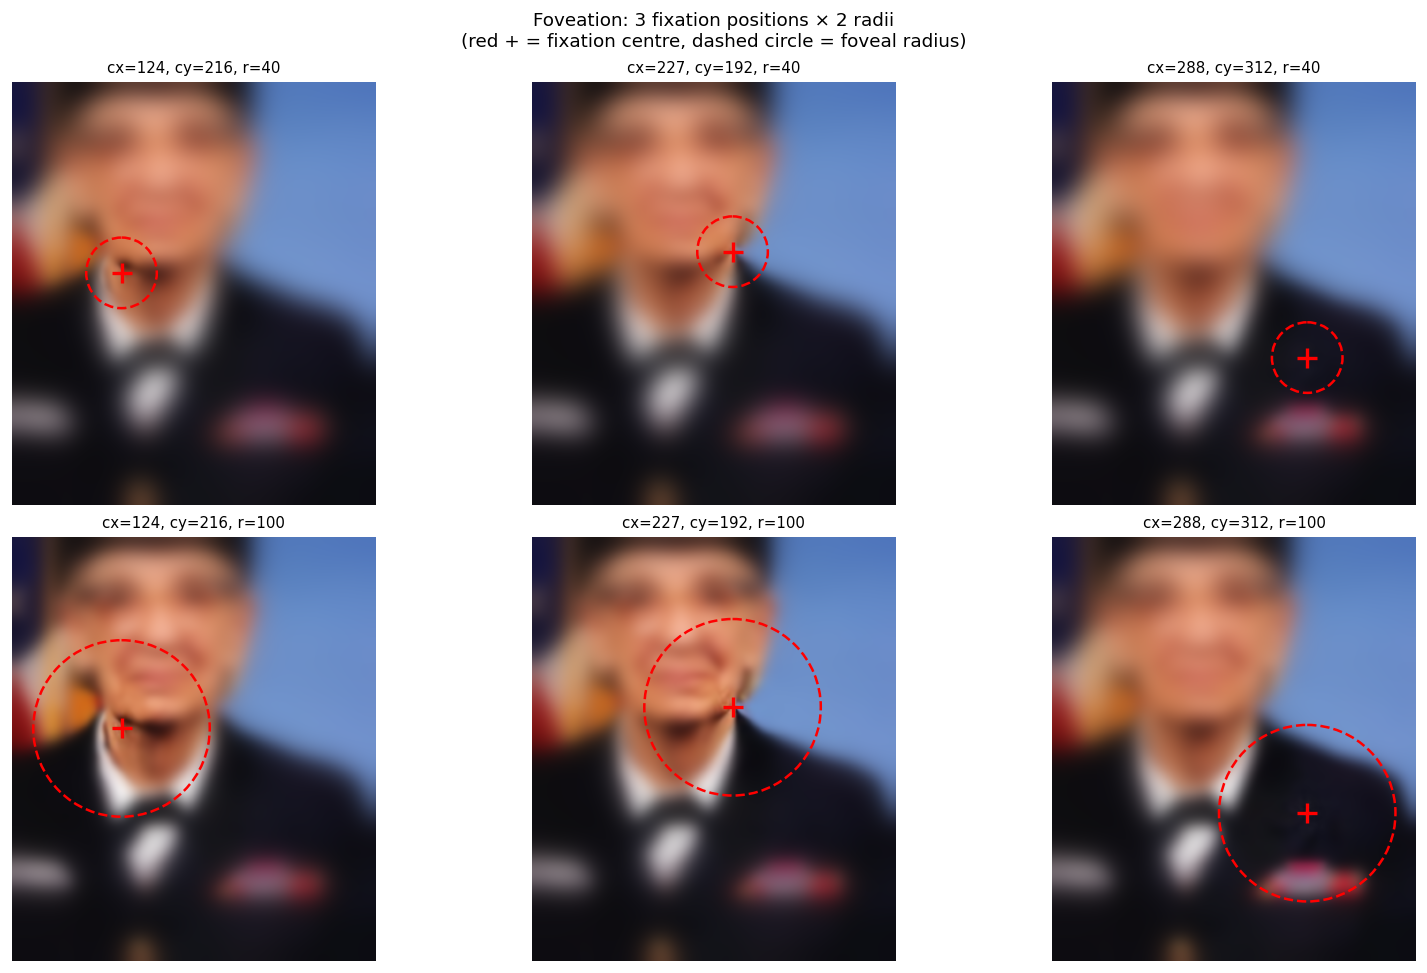

In [3]:
# Define fixation positions as fractions of image dimensions
fixations = [
    (0.30 * w, 0.45 * h),   # left side
    (0.55 * w, 0.40 * h),   # centre-top
    (0.70 * w, 0.65 * h),   # right-bottom
]
radii = [40.0, 100.0]   # tight fovea vs broad fovea

fig, axes = plt.subplots(2, 3, figsize=(13.0, 8.0), constrained_layout=True)

for row, r in enumerate(radii):
    for col, (cx, cy) in enumerate(fixations):
        ax = axes[row, col]
        fov_img = foveate(cx, cy, r)
        ax.imshow(fov_img, interpolation="bilinear")

        # Mark fixation centre
        ax.plot(cx, cy, 'r+', ms=12, mew=2, zorder=5)

        # Draw foveal radius circle
        circle = patches.Circle((cx, cy), radius=r,
                                 edgecolor='red', facecolor='none',
                                 linewidth=1.5, linestyle='--', zorder=5)
        ax.add_patch(circle)

        ax.set_title(f"cx={cx:.0f}, cy={cy:.0f}, r={r:.0f}", fontsize=9)
        ax.axis("off")

fig.suptitle("Foveation: 3 fixation positions × 2 radii\n"
             "(red + = fixation centre, dashed circle = foveal radius)",
             fontsize=11)
plt.savefig(OUT / "_foveation_grid.png", bbox_inches="tight")

## Interactive exploration

The three sliders below control:

- **Center X** — horizontal position of the fixation point $x_f^{(1)}$ (in pixels, $0$ = left edge).
- **Center Y** — vertical position $x_f^{(2)}$ (in pixels, $0$ = top edge).
- **Radius** — the eccentricity scale $r$. A small radius produces a narrow sharp fovea; a large radius keeps the image sharp across a broad region.

The foveation weight $w(x) = 1 - e^{-d(x)/r}$ reaches $1 - e^{-1} \approx 0.63$ at $d = r$ and $1 - e^{-2} \approx 0.86$ at $d = 2r$, so the circle marks the half-transition zone.

## Static snapshot

This cell saves `snippet.png` — a representative $2\times 3$ grid used as the gallery thumbnail. The `STATIC_SNAPSHOT` flag ensures it runs in automated execution contexts.

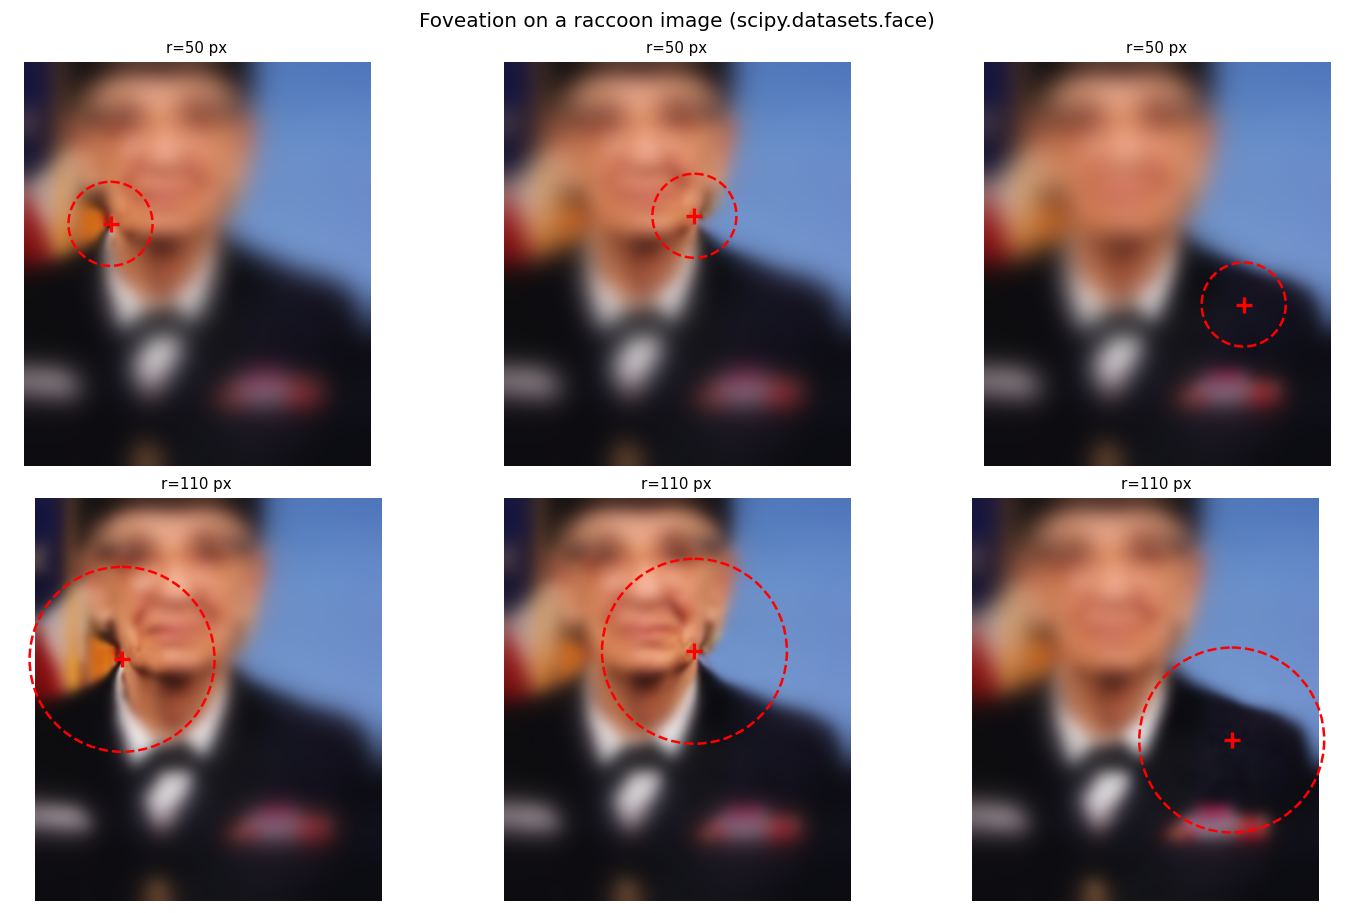

In [4]:
STATIC_SNAPSHOT = True

if STATIC_SNAPSHOT:
    snap_fixations = [
        (0.25 * w, 0.40 * h),
        (0.55 * w, 0.38 * h),
        (0.75 * w, 0.60 * h),
    ]
    snap_radii = [50.0, 110.0]

    fig, axes = plt.subplots(2, 3, figsize=(12.0, 7.5), constrained_layout=True)

    for row, r in enumerate(snap_radii):
        for col, (cx, cy) in enumerate(snap_fixations):
            ax = axes[row, col]
            fov_img = foveate(cx, cy, r)
            ax.imshow(fov_img, interpolation="bilinear")
            ax.plot(cx, cy, 'r+', ms=10, mew=2, zorder=5)
            circ = patches.Circle((cx, cy), radius=r,
                                   edgecolor='red', facecolor='none',
                                   linewidth=1.5, linestyle='--', zorder=5)
            ax.add_patch(circ)
            ax.set_title(f"r={r:.0f} px", fontsize=9)
            ax.axis("off")

    axes[0, 0].set_ylabel("small radius", fontsize=9)
    axes[1, 0].set_ylabel("large radius", fontsize=9)
    fig.suptitle("Foveation on a raccoon image (scipy.datasets.face)",
                 fontsize=12)
    fig.savefig(OUT / "snippet.png", bbox_inches="tight")

## Takeaways

- **Eccentricity-dependent blur** faithfully models the fall-off of human visual acuity: sharp near the fixation centre, progressively blurred with distance.
- The **multi-scale pre-computation** strategy (a small fixed set of Gaussian-blurred images, then per-pixel interpolation) makes the foveation function fast and vectorised — no per-pixel convolution is needed.
- The **radius parameter** $r$ controls the spatial extent of the foveal zone. A small $r$ concentrates sharpness in a tight region; a large $r$ spreads sharpness broadly across the image.
- The **exponential weight** $w(x) = 1 - e^{-d/r}$ is a smooth, monotone function that reaches half-maximum near $d \approx 0.7 r$ and saturates at large eccentricity.
- Foveation is used in **gaze-contingent rendering** (VR/AR), **image compression**, and as a model of **peripheral visual processing** in computational neuroscience.

## Bibliography

- Geisler, W. S. and Perry, J. S. (1998). Real-time foveated multiresolution system for low-bandwidth video communication. *SPIE Human Vision and Electronic Imaging III*, vol. 3299.
- Kortum, P. T. and Geisler, W. S. (1996). Implementation of a foveated image coding system for image bandwidth reduction. *SPIE Human Vision and Electronic Imaging*, vol. 2657.
- Wang, Z. and Bovik, A. C. (2006). *Modern Image Quality Assessment*. Morgan & Claypool Publishers.
- Rosenholtz, R., Huang, J., Raj, A., Balas, B. J., and Ilie, L. (2012). A summary statistic representation in peripheral vision explains visual crowding. *Journal of Vision*, 12(3).
- Anstis, S. M. (1974). A chart demonstrating variations in acuity with retinal position. *Vision Research*, 14(7), 589–592.